<a href="https://colab.research.google.com/github/murtazaansari2504/QGAN-and-GAN/blob/main/QGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio

In [2]:
import sys
print(sys.executable)



/usr/bin/python3


In [3]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio

In [4]:
import torch
print(torch.__version__)

2.11.0+cu128


In [5]:
import torch

# Create known parameters
weight = 0.7
bias = 0.3

# Generate 500 data points
start = 0
end = 1
step = 0.002  # (end - start) / 500

# Create input features (X)
X = torch.arange(start, end, step).unsqueeze(dim=1)

# Create target labels (y) using the equation y = wx + b
y = weight * X + bias

# Display the first 400 samples
if __name__ == "__main__":
  print("First 400 values of X:")
  print(X[:400])

  print("\nFirst 400 values of y:")
  print(y[:400])

# Display tensor shapes
  print("\nShape of X:", X.shape)
  print("Shape of y:", y.shape)

  # Display total number of samples
  print("\nNumber of X samples:", len(X))
  print("Number of y samples:", len(y))

First 400 values of X:
tensor([[0.0000],
        [0.0020],
        [0.0040],
        [0.0060],
        [0.0080],
        [0.0100],
        [0.0120],
        [0.0140],
        [0.0160],
        [0.0180],
        [0.0200],
        [0.0220],
        [0.0240],
        [0.0260],
        [0.0280],
        [0.0300],
        [0.0320],
        [0.0340],
        [0.0360],
        [0.0380],
        [0.0400],
        [0.0420],
        [0.0440],
        [0.0460],
        [0.0480],
        [0.0500],
        [0.0520],
        [0.0540],
        [0.0560],
        [0.0580],
        [0.0600],
        [0.0620],
        [0.0640],
        [0.0660],
        [0.0680],
        [0.0700],
        [0.0720],
        [0.0740],
        [0.0760],
        [0.0780],
        [0.0800],
        [0.0820],
        [0.0840],
        [0.0860],
        [0.0880],
        [0.0900],
        [0.0920],
        [0.0940],
        [0.0960],
        [0.0980],
        [0.1000],
        [0.1020],
        [0.1040],
        [0.1060],
     

In [6]:
import sys
!{sys.executable} -m pip install pandas

In [7]:
import pandas as pd

df = pd.DataFrame({
    "X": X.squeeze().numpy(),
    "y": y.squeeze().numpy()
})

df.to_csv("linear_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [8]:
import sys
!{sys.executable} -m pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.0 MB/s eta 0:00:00


In [9]:
#Generator Circuit

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

n_qubits = 4 # 2^4 i.e total 16 possible states

theta = ParameterVector("theta", 8) #Generation of theta(Trainable parameters, Same as weights of GAN)
#Total 8 trainable parameters

qc = QuantumCircuit(n_qubits) #Empty circuit of 4 Qubits

for i in range(n_qubits):
    qc.ry(theta[i], i) #RY gate, to change the probability of 0 & 1 acc to theta.

for i in range(n_qubits-1):
    qc.cx(i, i+1) #CX gate for connecting or entagling two Qubits

for i in range(n_qubits):
    qc.ry(theta[i+4], i) #again ry gate for more thetas such as 5 [1+4]

qc.measure_all()

In [ ]:
#A parameterized quantum circuit consisting of four qubits was used as the generator. The circuit employed two layers of trainable RY rotation gates separated by a chain of CNOT gates to introduce entanglement. Measurement outcomes were sampled to generate synthetic data distributions for adversarial learning.

In [10]:
import sys
!{sys.executable} -m pip install qiskit_aer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 118.3 MB/s eta 0:00:00


In [11]:
import numpy as np

params = np.random.uniform(
    0,
    2*np.pi,
    len(theta)
) #Generation of datapoints between 0 to 2pi and total number of datapoints is len(theta)
#same as random weights in GAN, it uses random rotation angles i.e theta
bound_qc = qc.assign_parameters(
    dict(zip(theta, params))
) #Symbolic circuit to executable circuit. i.e RY(00) ---> RY(1.53) or qc.ry(theta[0],0) ---> qc.ry(1.24,0)
from qiskit_aer import AerSimulator

backend = AerSimulator()

result = backend.run(
    bound_qc,
    shots=1000  #will execute 1000 times
).result()

counts = result.get_counts() #Counts is measurement frequency

In [ ]:
#Randomly initialized circuit parameters were assigned to the trainable rotation gates. The parameterized quantum circuit was executed on the Aer quantum simulator with 1000 measurement shots. The resulting measurement counts were used to estimate the probability distribution generated by the quantum model.

In [12]:
#binary to decimal then decimal to bitstring
def bitstring_to_value(bitstring):

    integer = int(bitstring,2) #binary to decimal

    value = -1 + (
        integer/(2**4 -1)
    )*2 #decimal to bitstring...

    return value

In [13]:
fake_samples = []

for state,count in counts.items():

    value = bitstring_to_value(state)

    fake_samples.extend(
        [value]*count #will add the exact frequency acc to the counts in bitstring manner.
    )

In [14]:
fake_samples = np.array(
    fake_samples
).reshape(-1,1) #list to array for ML libraries

In [15]:
import torch
import torch.nn as nn

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(1,16),
            nn.ReLU(), #linear to non linear data. (Negative integer will convert to zero and it will result into non linearity)

            nn.Linear(16,8),
            nn.ReLU(),

            nn.Linear(8,1),
            nn.Sigmoid() #σ(x) = 1/(1+e^(-x))
            #sigmoid will convert output range b/w 0 to 1 only as discriminator gives probability distribution
        )

    def forward(self,x):
        return self.model(x)

In [ ]:
#The generated samples were converted into PyTorch tensors and assigned binary labels. Real samples were labeled as 1, while quantum-generated samples were labeled as 0. Binary Cross-Entropy (BCE) loss was employed to quantify the discriminator’s classification error.

In [16]:
D = Discriminator()
real = torch.FloatTensor(X) #Array to tensor as nn works only with tensors.

In [17]:
print (X.shape)

torch.Size([500, 1])


In [18]:
fake = torch.FloatTensor(fake_samples)

In [19]:
real_labels = torch.ones(len(real),1)

fake_labels = torch.zeros(len(fake),1)

In [20]:
criterion = nn.BCELoss()

In [ ]:
#The generated samples were converted into PyTorch tensors and assigned binary labels. Real samples were labeled as 1, while quantum-generated samples were labeled as 0. Binary Cross-Entropy (BCE) loss was employed to quantify the discriminator’s classification error.

In [21]:
loss_real = criterion(
    D(real),
    real_labels
)

loss_fake = criterion(
    D(fake),
    fake_labels
)

loss_D = loss_real + loss_fake #calculating whole loss.

In [ ]:
#The discriminator loss was computed as the sum of Binary Cross-Entropy losses on real and quantum-generated samples. Real samples were assigned target label 1, while generated samples were assigned target label 0. The combined loss quantified the discriminator’s ability to distinguish between authentic and generated data.

In [22]:
new_params = (
    params +
    np.random.normal(
        0,
        0.1,
        len(params)
    )
)# modigying parameters with some random changes

In [23]:
D(fake)

tensor([[0.4469],
        [0.4469],
        [0.4469],
        [0.4469],
        [0.4469],
        [0.4469],
        [0.4469],
        [0.4469],
        [0.4469],
        [0.5531],
        [0.5531],
        [0.5531],
        [0.5531],
        [0.5531],
        [0.5531],
        [0.5531],
        [0.5510],
        [0.5510],
        [0.5510],
        [0.5510],
        [0.5510],
        [0.5510],
        [0.5510],
        [0.5510],
        [0.5510],
        [0.5510],
        [0.5510],
        [0.5510],
        [0.5510],
        [0.5510],
        [0.5510],
        [0.5510],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0.5203],
        [0

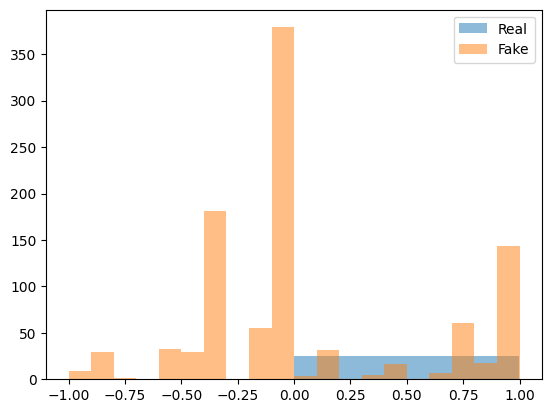

In [24]:
import matplotlib.pyplot as plt

plt.hist(
    X,
    bins=20,
    alpha=0.5,
    label="Real"
)

plt.hist(
    fake_samples,
    bins=20,
    alpha=0.5,
    label="Fake"
)

plt.legend()
plt.show()

In [25]:
print(real.min())
print(real.max())
print(loss_D)

tensor(0.)
tensor(0.9980)
tensor(1.3349, grad_fn=<AddBackward0>)


In [26]:
print("Real:", D(real).mean().item())
print("Fake:", D(fake).mean().item())

Real: 0.5478416681289673
Fake: 0.5188090801239014


In [27]:
import torch.optim as optim

optimizer_D = optim.Adam(
    D.parameters(),
    lr=0.001
) #using Adam optimizer

In [28]:
optimizer_D.zero_grad()

loss_real = criterion(
    D(real),
    real_labels
) #Calculating the discriminator loss for real data

loss_fake = criterion(
    D(fake),
    fake_labels
) #Calculating te discriminator loss for fake data

loss_D = loss_real + loss_fake

loss_D.backward() #Backpropogation, will see which theta or weight results into changes of loss

optimizer_D.step() #will optimize the specific theta or weight.

print(loss_D.item())

1.3348946571350098


In [ ]:
#The discriminator parameters were optimized using the Adam optimizer. Gradients were computed through backpropagation of the Binary Cross-Entropy loss, and network weights were updated to improve discrimination between real and quantum-generated samples.

In [29]:
for epoch in range(100):

    optimizer_D.zero_grad()

    loss_real = criterion(
        D(real),
        real_labels
    )

    loss_fake = criterion(
        D(fake),
        fake_labels
    )

    loss_D = loss_real + loss_fake

    loss_D.backward()

    optimizer_D.step()

print("Training Complete")

Training Complete


In [ ]:
#The discriminator was trained for 100 epochs using the Adam optimizer and Binary Cross-Entropy loss. During this phase, real samples and a fixed set of quantum-generated samples were used to improve the discriminator’s classification capability.

In [30]:
print("Real:", D(real).mean().item())
print("Fake:", D(fake).mean().item())

Real: 0.5345868468284607
Fake: 0.3810161054134369


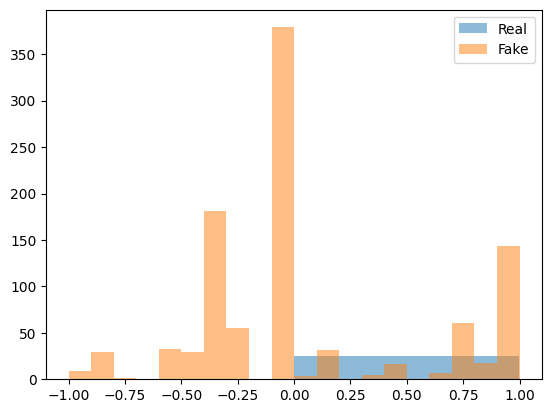

In [31]:
import matplotlib.pyplot as plt

plt.hist(real.numpy(), bins=20, alpha=0.5, label="Real")
plt.hist(fake.numpy(), bins=20, alpha=0.5, label="Fake")

plt.legend()
plt.show()

In [32]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator
import numpy as np

n_qubits = 4

theta = ParameterVector("θ", 8)

qc = QuantumCircuit(n_qubits)

# Layer 1
for i in range(4):
    qc.ry(theta[i], i)

# Entanglement
for i in range(3):
    qc.cx(i, i+1)

# Layer 2
for i in range(4):
    qc.ry(theta[i+4], i)

qc.measure_all()

# Random parameter values
params = np.random.uniform(
    0,
    2*np.pi,
    8
)

bound_qc = qc.assign_parameters(
    dict(zip(theta, params))
)

backend = AerSimulator()

result = backend.run(
    bound_qc,
    shots=500
).result()

counts = result.get_counts()

print(counts)

{'1100': 4, '1001': 6, '0101': 4, '0010': 35, '0000': 10, '0100': 6, '0011': 89, '0111': 76, '1011': 39, '1101': 23, '0001': 150, '1111': 28, '1010': 8, '1110': 8, '0110': 11, '1000': 3}


In [33]:
def bitstring_to_value(bitstring):

    integer = int(bitstring, 2)

    value = integer / 15

    return value

In [34]:
fake_samples = []

for state, count in counts.items():

    value = bitstring_to_value(state)

    fake_samples.extend([value] * count)

In [35]:
fake_samples = torch.FloatTensor(
    fake_samples
).reshape(-1,1)

print(fake_samples.shape)

torch.Size([500, 1])


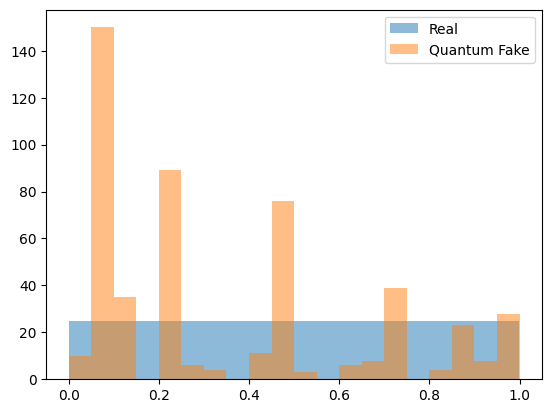

In [36]:
import matplotlib.pyplot as plt

plt.hist(
    real.numpy(),
    bins=20,
    alpha=0.5,
    label="Real"
)

plt.hist(
    fake_samples.numpy(),
    bins=20,
    alpha=0.5,
    label="Quantum Fake"
)

plt.legend()
plt.show()

In [37]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator
import numpy as np
import torch

n_qubits = 4

theta = ParameterVector("θ", 8)

qc = QuantumCircuit(n_qubits)

for i in range(4):
    qc.ry(theta[i], i)

for i in range(3):
    qc.cx(i, i+1)

for i in range(4):
    qc.ry(theta[i+4], i)

qc.measure_all()

backend = AerSimulator()

In [38]:
def bitstring_to_value(bitstring):

    integer = int(bitstring, 2)

    return integer / 15

In [39]:
def generate_fake_samples(params):

    bound_qc = qc.assign_parameters(
        dict(zip(theta, params))
    )

    result = backend.run(
        bound_qc,
        shots=500
    ).result()

    counts = result.get_counts()

    fake_samples = []

    for state, count in counts.items():

        value = bitstring_to_value(state)

        fake_samples.extend(
            [value] * count
        )

    fake_samples = torch.FloatTensor(
        fake_samples
    ).reshape(-1,1)

    return fake_samples

In [40]:
params = np.random.uniform(
    0,
    2*np.pi,
    8
)

fake = generate_fake_samples(params)

print(fake.shape)

torch.Size([500, 1])


In [41]:
def generator_score(fake):

    with torch.no_grad():

        score = D(fake).mean().item()

    return score

In [42]:
params = np.random.uniform(
    0,
    2*np.pi,
    8
)

fake = generate_fake_samples(params)

score = generator_score(fake)

print(score)

0.5181851387023926


In [43]:
best_score = -1

best_params = None

for trial in range(100):

    params = np.random.uniform(
        0,
        2*np.pi,
        8
    )

    fake = generate_fake_samples(params)

    score = generator_score(fake)

    print(
        f"Trial {trial}: {score}"
    )

    if score > best_score:

        best_score = score
        best_params = params

Trial 0: 0.5610264539718628
Trial 1: 0.5406094789505005
Trial 2: 0.546642005443573
Trial 3: 0.49499738216400146
Trial 4: 0.541293740272522
Trial 5: 0.53018718957901
Trial 6: 0.5317398905754089
Trial 7: 0.5350679755210876
Trial 8: 0.4945693612098694
Trial 9: 0.5630649328231812
Trial 10: 0.5653258562088013
Trial 11: 0.5266179442405701
Trial 12: 0.5014187693595886
Trial 13: 0.5274345874786377
Trial 14: 0.5210362672805786
Trial 15: 0.5655246376991272
Trial 16: 0.5389811992645264
Trial 17: 0.47545161843299866
Trial 18: 0.4556432068347931
Trial 19: 0.49355432391166687
Trial 20: 0.5553656816482544
Trial 21: 0.5565443634986877
Trial 22: 0.5327779054641724
Trial 23: 0.5678040981292725
Trial 24: 0.547441303730011
Trial 25: 0.560590922832489
Trial 26: 0.5565207600593567
Trial 27: 0.5678601264953613
Trial 28: 0.5424962639808655
Trial 29: 0.5231605768203735
Trial 30: 0.5200194120407104
Trial 31: 0.5675280094146729
Trial 32: 0.5267945528030396
Trial 33: 0.5067625641822815
Trial 34: 0.542773962020874

In [44]:
print(best_score)
print(best_params)

0.5706811547279358
[0.56534909 0.34155266 4.67386614 1.5496896  2.8220777  2.86073671
 1.28418505 1.58167642]


In [45]:
best_fake = generate_fake_samples(best_params)

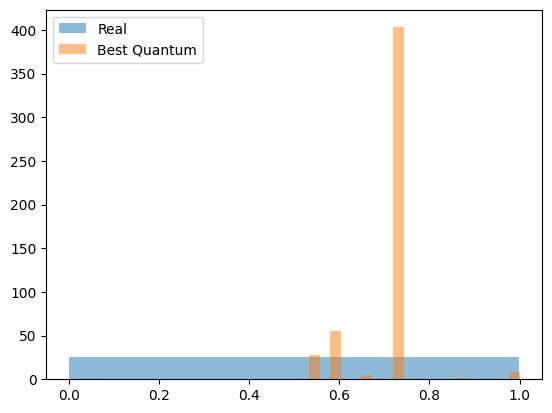

In [46]:
plt.hist(real.numpy(), bins=20,
         alpha=0.5, label="Real")

plt.hist(best_fake.numpy(), bins=20,
         alpha=0.5, label="Best Quantum")

plt.legend()
plt.show()

In [47]:
import torch

real_mean = real.mean()
fake_mean = best_fake.mean()

mse = (real_mean - fake_mean)**2

print("MSE:", mse.item())

MSE: 0.04508548974990845


In [48]:
print(best_score)

print(real.mean())

print(best_fake.mean())

print(mse)

0.5706811547279358
tensor(0.4990)
tensor(0.7113)
tensor(0.0451)


In [ ]:
#A hybrid QGAN with a 4-qubit variational quantum circuit was implemented and evaluated on a synthetic linear dataset. The generated samples achieved a discriminator score of 0.57 and an MSE of 0.045 with respect to the target distribution, demonstrating the capability of the quantum generator to approximate the underlying data distribution.